In [ ]:
source("./preprocess/utils.R")
library(mclust)
library(RColorBrewer)

parser <- ArgumentParser()
parser$add_argument("--task", type = "character", default = "atlas_disease_cl")
parser$add_argument("--method", type = "character", default = "midas_embed")
parser$add_argument("--experiment", type = "character", default = "c_2")
parser$add_argument("--model", type = "character", default = "default")
parser$add_argument("--reference", type = "character", default = "atlas_new")
parser$add_argument("--init_model", type = "character", default = "")
o <- parser$parse_known_args()[[1]]

config <- parseTOML("configs/data.toml")[[gsub("_transfer$|_ref_.*$", "", o$task)]]
config_ref <- parseTOML("configs/data.toml")[[gsub("_transfer$|_ref_.*$", "", o$reference)]]
config$raw_data_dirs <- c(config_ref$raw_data_dirs, config$raw_data_dirs[1:17])
subset_names <- basename(config$raw_data_dirs)
subset_ids <- sapply(seq_along(subset_names) - 1, toString)
input_dirs <- pj("result", o$task, o$experiment, o$model, "predict", o$init_model, paste0("subset_", subset_ids))
pp_dir <- pj("data", "processed", o$reference)
output_dir <- pj("result", "comparison", o$task, o$method, o$experiment, o$model, o$init_model)
mkdir(output_dir, remove_old = F)
label_paths <- pj(config$raw_data_dirs, "label_seurat_cca", "l1.csv")

K <- parseTOML("configs/model.toml")[["default"]]$dim_c
l <- 7.5  # figure size
L <- 10   # figure size
m <- 0.5  # legend margin

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated

In [ ]:
z_list <- list()
cell_name_list <- list()
label_list <- list()
is_label <- T
subset_name_list <- list()
S <- length(subset_names)
for (i in seq_along(subset_names)) {
    subset_name <- subset_names[i]
    z_dir    <- pj(input_dirs[i], "z", "joint")
    fnames <- dir(path = z_dir, pattern = ".csv$")
    fnames <- str_sort(fnames, decreasing = F)

    z_subset_list <- list()
    N <- length(fnames)
    for (n in seq_along(fnames)) {
        message(paste0("Loading Subset ", i, "/", S, ", File ", n, "/", N))
        z_subset_list[[n]] <- read.csv(file.path(z_dir, fnames[n]), header = F)
    }
    z_list[[subset_name]] <- bind_rows(z_subset_list)

    if (i < 35) {
        cell_name_list[[subset_name]] <- read.csv(pj(pp_dir, paste0("subset_", subset_ids[i]),
            "cell_names.csv"), header = T)[, 2]    
    } else if (i < 45) {
        cell_name_list[[subset_name]] <- read.csv(pj(pj("data", "processed", "covid"), paste0("subset_", as.integer((subset_ids[i]))-34),
            "cell_names.csv"), header = T)[, 2]
    } else if (i < 52) {
        cell_name_list[[subset_name]] <- read.csv(pj(pj("data", "processed", "flu_a"), paste0("subset_", as.integer((subset_ids[i]))-44),
            "cell_names.csv"), header = T)[, 2]
    } else if (i >= 52) {
        cell_name_list[[subset_name]] <- read.csv(pj(pj("data", "processed", "tuber"), paste0("subset_", as.integer((subset_ids[i]))-51),
            "cell_names.csv"), header = T)[, 2]
    }
    if (file.exists(label_paths[i])) {
        if (grepl('lane', subset_names[i])) {
            label_list[[subset_name]] <- read.csv(gsub("l1.csv", "l1_singler.csv", label_paths[i]), header = T)[, 2]
        } else {
            label_list[[subset_name]] <- read.csv(label_paths[i], header = T)[, 2]
        }
    } else {
        is_label <- F
    }
    
    subset_name_list[[subset_name]] <- rep(subset_name, length(cell_name_list[[subset_name]]))
}

Loading Subset 1/51, File 1/29

Loading Subset 1/51, File 2/29

Loading Subset 1/51, File 3/29

Loading Subset 1/51, File 4/29

Loading Subset 1/51, File 5/29

Loading Subset 1/51, File 6/29

Loading Subset 1/51, File 7/29

Loading Subset 1/51, File 8/29

Loading Subset 1/51, File 9/29

Loading Subset 1/51, File 10/29

Loading Subset 1/51, File 11/29

Loading Subset 1/51, File 12/29

Loading Subset 1/51, File 13/29

Loading Subset 1/51, File 14/29

Loading Subset 1/51, File 15/29

Loading Subset 1/51, File 16/29

Loading Subset 1/51, File 17/29

Loading Subset 1/51, File 18/29

Loading Subset 1/51, File 19/29

Loading Subset 1/51, File 20/29

Loading Subset 1/51, File 21/29

Loading Subset 1/51, File 22/29

Loading Subset 1/51, File 23/29

Loading Subset 1/51, File 24/29

Loading Subset 1/51, File 25/29

Loading Subset 1/51, File 26/29

Loading Subset 1/51, File 27/29

Loading Subset 1/51, File 28/29

Loading Subset 1/51, File 29/29

Loading Subset 2/51, File 1/24

Loading Subset 2/51,

In [ ]:
obj <- LoadH5Seurat("./result/comparison/atlas_disease_cl/midas_embed/c_2/default/obj.h5seurat")

Validating h5Seurat file

Initializing rna with data



Adding counts for rna

Adding miscellaneous information for rna

Adding reduction c

Adding cell embeddings for c

Adding miscellaneous information for c

Adding reduction c.umap

Adding cell embeddings for c.umap

Adding miscellaneous information for c.umap

Adding command information

Adding cell-level metadata

Adding miscellaneous information

Adding tool-specific results



In [3]:
# Create seurat object
rna <- t(data.matrix(bind_rows(z_list))) * 0  # pseudo rna counts
colnames(rna) <- do.call("c", unname(cell_name_list))
rownames(rna) <- paste0("rna-", seq_len(nrow(rna)))
obj <- CreateSeuratObject(counts = rna, assay = "rna")

z <- data.matrix(bind_rows(z_list))
c <- z[, 1:K]
colnames(c) <- paste0("c_", seq_len(ncol(c)))
rownames(c) <- colnames(obj)
obj[["c"]] <- CreateDimReducObject(embeddings = c, key = "c_", assay = "rna")

obj@meta.data$batch <- factor(x = do.call("c", unname(subset_name_list)), levels = subset_names)
table(obj@meta.data$batch)[unique(obj@meta.data$batch)]

obj


                lll_ctrl                 lll_stim                 dig_ctrl 
                    7361                     5897                    10190 
                dig_stim                       w1                       w3 
                    9527                     7325                     6587 
                      w4                       w5                       w6 
                    6897                     6910                     7137 
            tea_multi_w1             tea_multi_w2 10x_multiome_chrom_x_10k 
                    6096                     7284                     9868 
10x_multiome_chrom_c_10k    10x_multiome_arc2_10k     10x_multiome_arc2_3k 
                    9582                    11116                     2566 
               asap_ctrl                asap_stim                cite_ctrl 
                    4255                     5241                     5086 
               cite_stim                     p1_0                     p2_0 
           

An object of class Seurat 
34 features across 366420 samples within 1 assay 
Active assay: rna (34 features, 0 variable features)
 1 dimensional reduction calculated: c

In [4]:
# Generate UMAP for visualization
obj <- RunUMAP(obj, reduction = 'c', dims = 1:K, reduction.name = 'c.umap')
SaveH5Seurat(obj, pj(output_dir, "obj.h5seurat"), overwrite = TRUE)
# obj <- LoadH5Seurat(pj(output_dir, "obj.h5seurat"), reductions = "c.umap")

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
07:56:16 UMAP embedding parameters a = 0.9922 b = 1.112

07:56:16 Read 366420 rows and found 32 numeric columns

07:56:16 Using Annoy for neighbor search, n_neighbors = 30

07:56:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

07:57:11 Writing NN index file to temp file /tmp/RtmpsYjIGf/filed6a633b01295

07:57:11 Searching Annoy index using 4 threads, search_k = 3000

07:58:07 Annoy recall = 100%

07:58:08 Commencing smooth kNN distance calibration using 4 threads
 with target n_neighbo

In [ ]:
# set groups for highlighting
obj@meta.data$highlight <- "Unselected"
select_mask <- obj@meta.data$batch %in% subset_names[45:51]

cell_label <- gsub(" cell", "", read.csv(pj(output_dir, "label_gt_nonumap_new.csv"), header = F)[, 1])
obj@meta.data$highlight[select_mask] <- cell_label

# Set colors
cell_label_unique <- unique(cell_label)
labels <- str_sort(cell_label_unique)

col_select <- c("#8FC36D", "#f54646", "#4472c4", "#ff00ff", "#82B4ed", "#D4aaff", "#8566a3", "#008000", "#fff300", "#085308")
pal <- col_select
label_to_color <- list()
for (i in seq_along(labels)) {
    label_to_color[[labels[i]]] <- pal[i]
}
cols <- c("#E5E5E5")
for (label in labels) {
    cols <- c(cols, label_to_color[[label]])
}

order <- c(rev(labels), "Unselected")


# plot
p1 <- dim_plot(obj, w = L+2, h = L, reduction = 'c.umap', no_axes = T, order = order, raster = F, rater_dpi = 600,
              split.by = NULL, group.by = "highlight", label = F, repel = T, label.size = 4, pt.size = 0.05, 
              shuffle = F, cols = cols, legend = T, return_plt = T, save_path = pj(output_dir, paste(o$task,
              o$method, o$experiment, o$model, o$init_model, "c_merged_label_l1", sep = "_"))) +
    labs(colour = "Singler cell type")

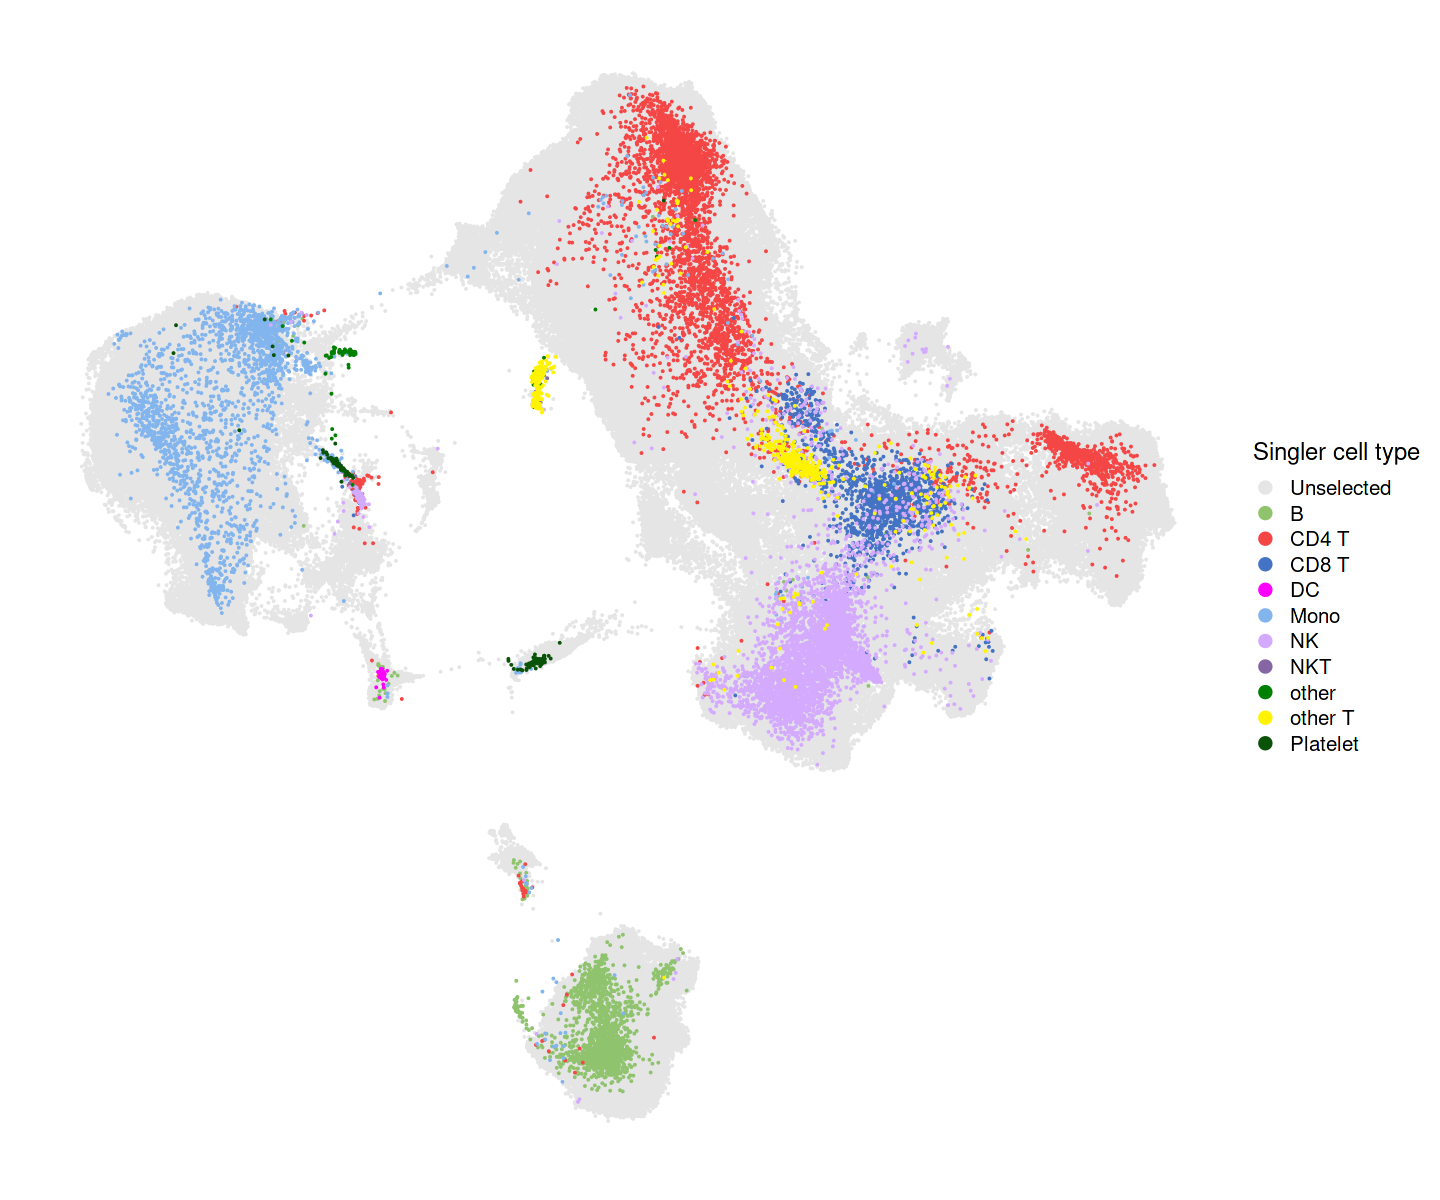

In [11]:
p1

In [7]:
obj@meta.data$highlight <- "Unselected"
select_mask <- obj@meta.data$batch %in% subset_names[45:51]
cell_label <- gsub(" cells", "", read.csv(pj(output_dir, "label_transferred_nonumap_new.csv"), header = F)[, 1])
obj@meta.data$highlight[select_mask] <- cell_label

# Set colors
cell_label_unique <- unique(cell_label)
labels <- str_sort(cell_label_unique)

col_13 <- c("#8FC36D", "#82B4ed", "#0c57a2", "#f1c232", "#f54646", "#ff69b4", "#6fa3ef", "#4472c4",
            "#006280", "#ff00ff", "#14e6e6", "#611154", "#ad6800", "#024255", "#c080ff", "#D4aaff", 
            "#b0b8ff", "#ff00bb94", "#00ad42", "#eee8aa", "#006400", "#2f4f4f")

pal <- c(col_13, "#9500ff")
label_to_color <- list()
for (i in seq_along(labels)) {
    label_to_color[[labels[i]]] <- pal[i]
}
cols <- c("#E5E5E5")
for (label in labels) {
    cols <- c(cols, label_to_color[[label]])
}

order <- c(rev(labels), "Unselected")

# plot
p2 <- dim_plot(obj, w = L+2, h = L, reduction = 'c.umap', no_axes = T, order = order, raster = F, rater_dpi = 600,
              split.by = NULL, group.by = "highlight", label = F, repel = T, label.size = 4, pt.size = 0.05, 
              shuffle = F, cols = cols, legend = T, return_plt = T, save_path = pj(output_dir, paste(o$task,
              o$method, o$experiment, o$model, o$init_model, "c_merged_label_transfer", sep = "_"))) +
    labs(colour = "MIRACLE cell type")

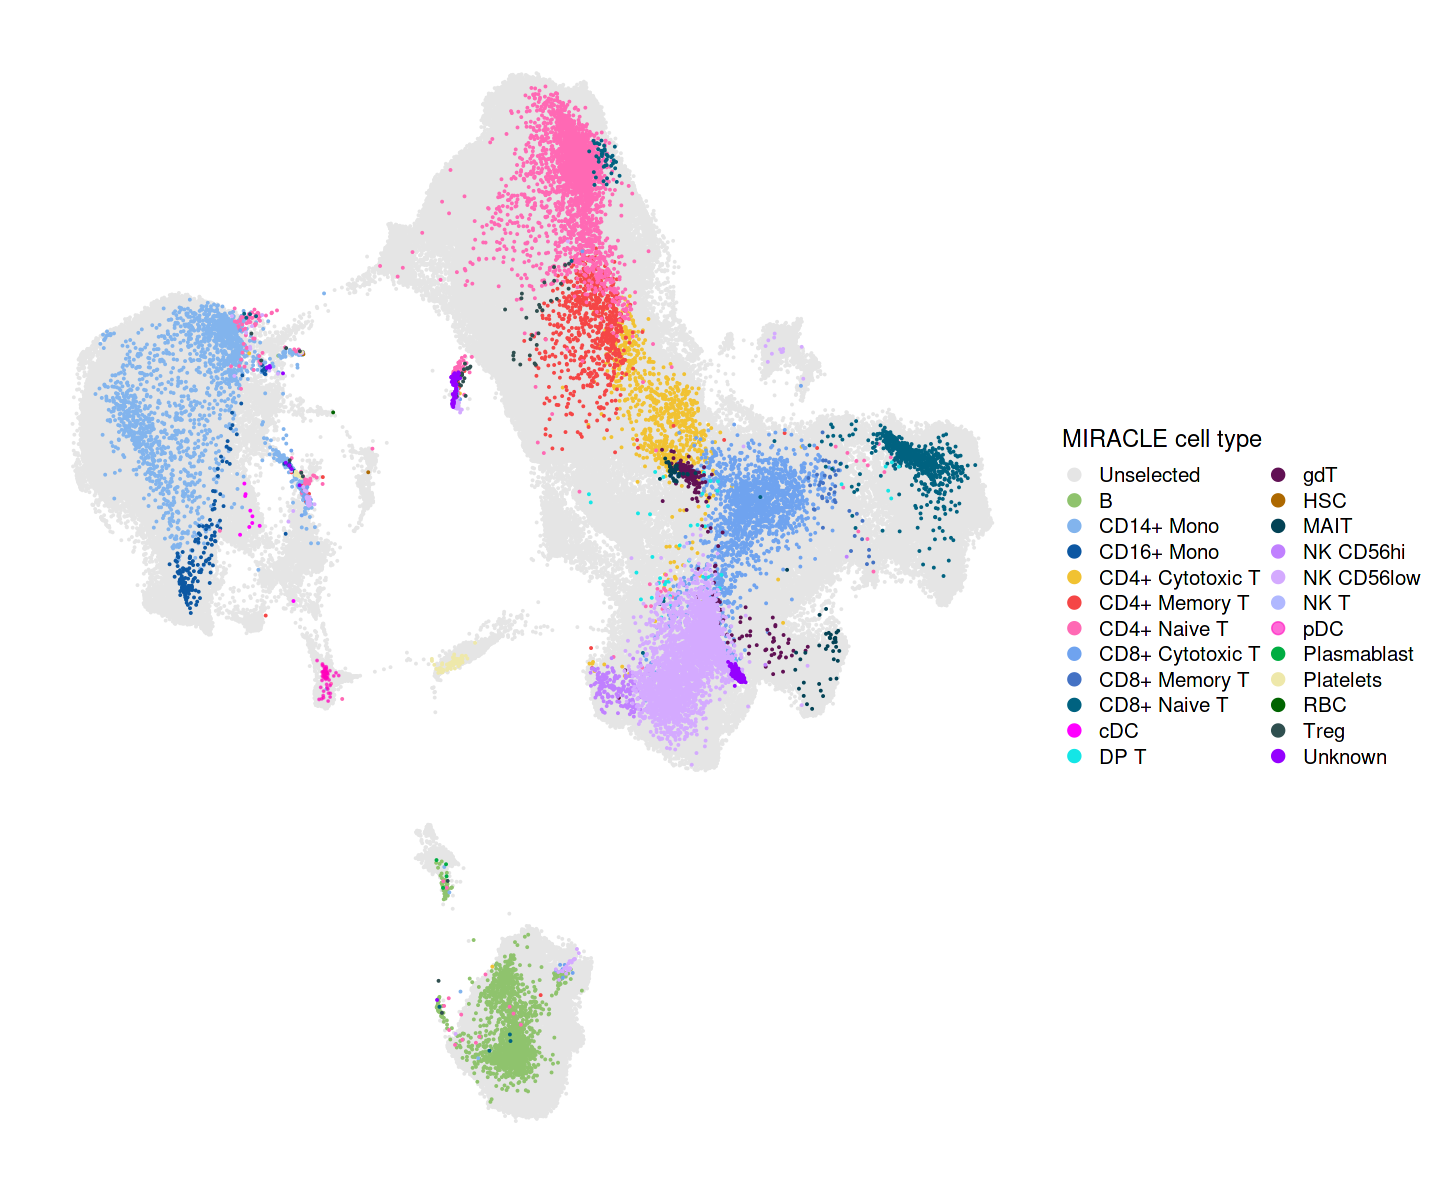

In [8]:
p2#0.98

In [ ]:
cell_label <- read.table("./analysis/atlas_label/atlas_disease_2_latest.csv", sep = ",", head = FALSE)[[2]][2:366421]
obj <- AddMetaData(object = obj,  
                    metadata = unname(cell_label),    
                    col.name = "atlas_new")

In [ ]:
cell_colors <- c(
  'B' = "#8FC36D",
  'CD14+ Mono' = "#82B4ed",
  'CD16+ Mono' = "#0c57a2",
  'CD4+ Cytotoxic T' = "#f1c232",
  'CD4+ Memory T' = "#f54646",
  'CD4+ Naive T' = "#ff69b4",
  'CD8+ Cytotoxic T' = "#6fa3ef",
  'CD8+ Memory T' = "#4472c4",
  'CD8+ Naive T' = "#006280",
  'cDC' = "#ff00ff",
  'DP T' = "#14e6e6",
  'gdT' = "#611154",
  'HSC' = "#ad6800",
  'MAIT' = "#024255",
  'NK CD56hi' = "#c080ff",
  'NK CD56low' = "#D4aaff",
  'NK T' = "#b0b8ff",
  'pDC' = "#ff00bb94",
  'Platelets' = "#eee8aa",
  'Plasmablast' = "#00ad42",
  'RBC' = "#006400",
  'T_HERC1' = "#278a8a",
  'Treg' = "#2f4f4f"
)

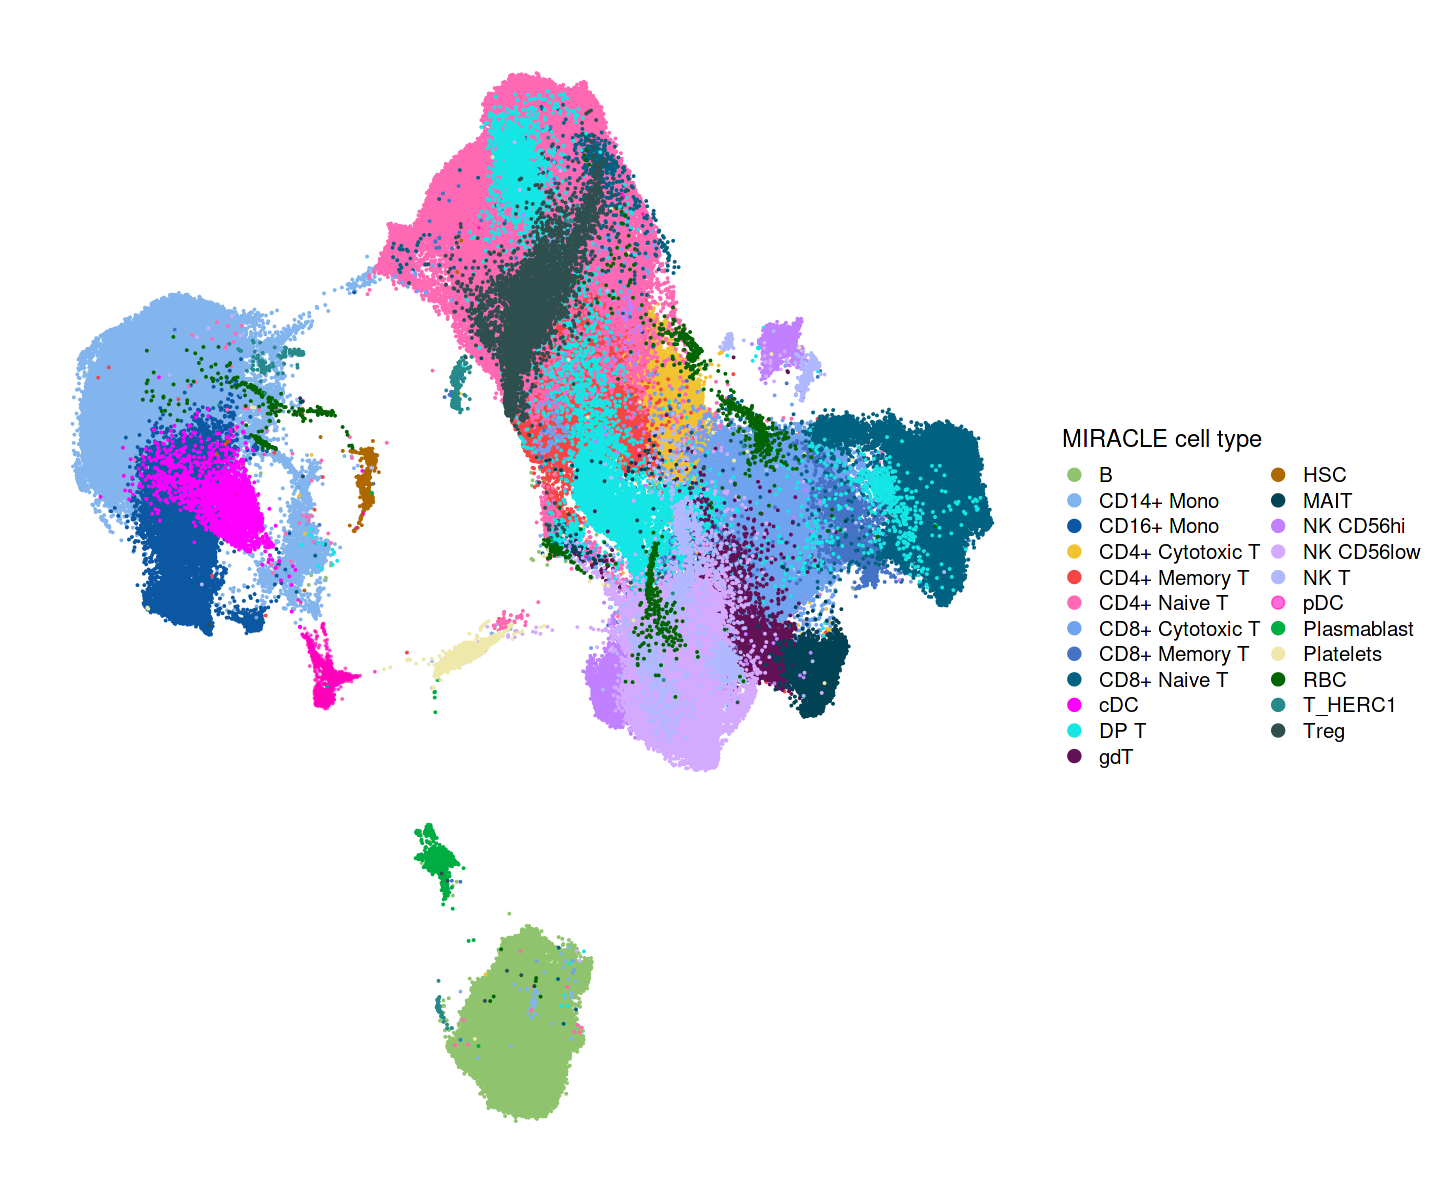

In [5]:
cell_label_unique <- unique(cell_label)
labels <- str_sort(cell_label_unique)

order <- c(rev(labels))

obj$atlas_new <- factor(obj$atlas_new, levels = sort(unique(obj$atlas_new)))
p3 <- dim_plot(obj, w = L+2, h = L, reduction = 'c.umap', no_axes = T, order = order, raster = F, rater_dpi = 600,
              split.by = NULL, group.by = "atlas_new", label = F, repel = T, label.size = 4, pt.size = 0.05, 
              shuffle = F, cols = cell_colors, legend = T, return_plt = T) +
    labs(colour = "MIRACLE cell type")# + theme(legend.position = "none")
p3

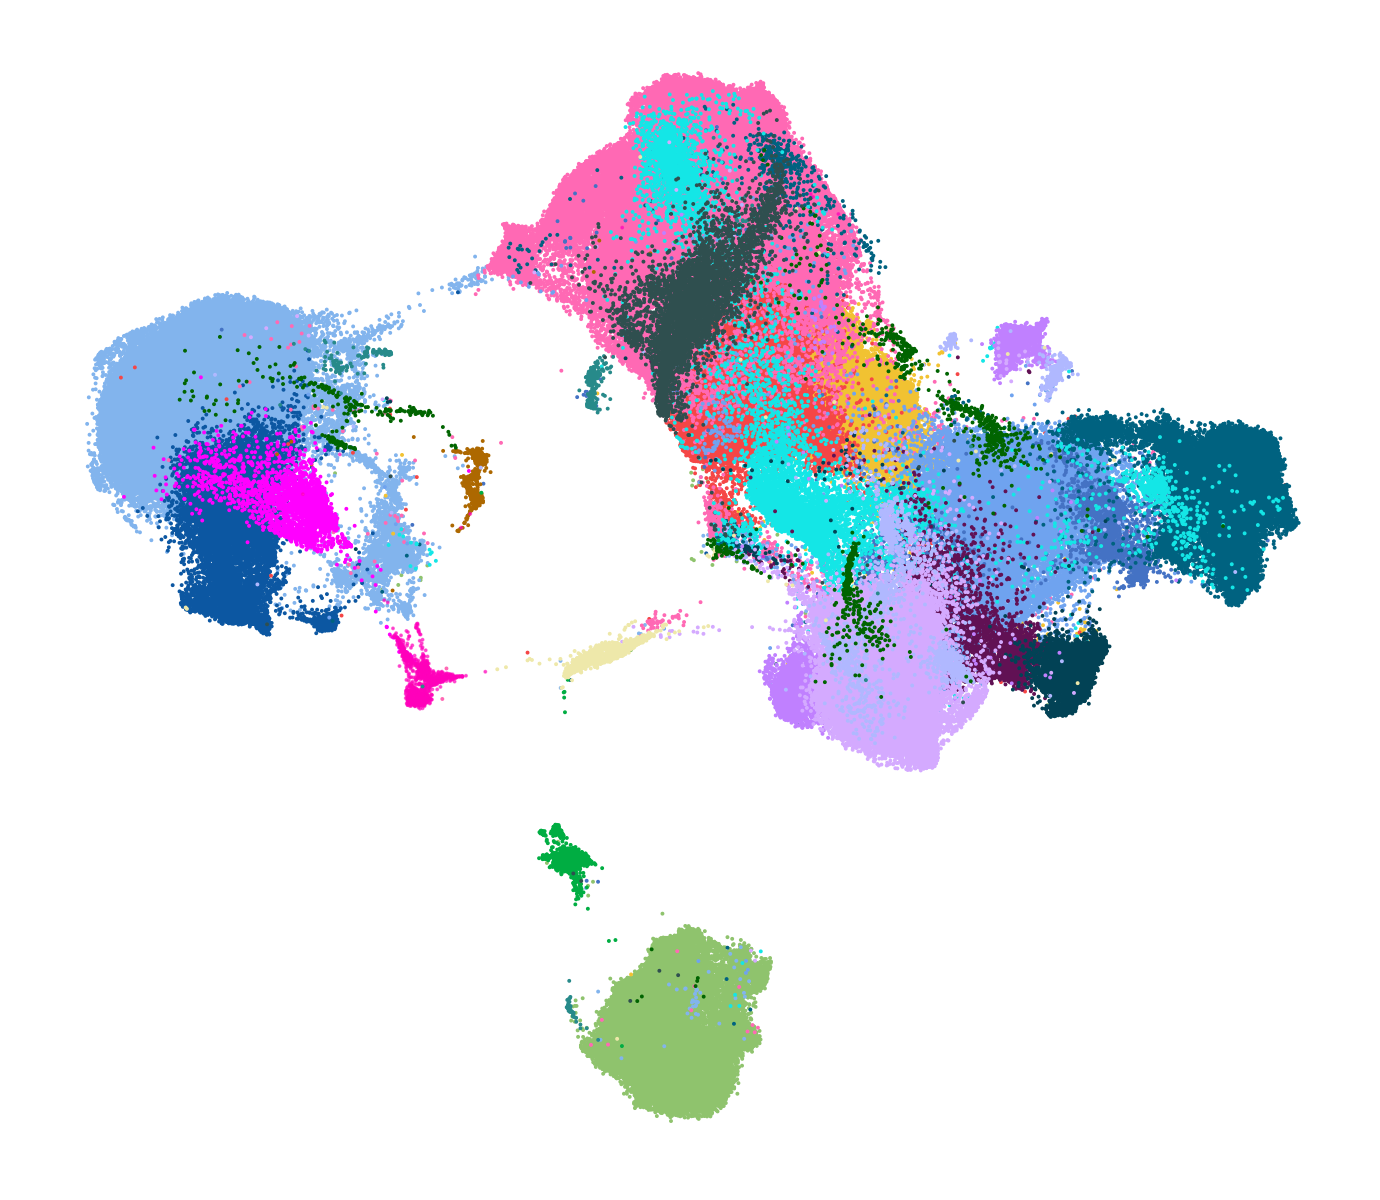

In [ ]:
save_dir <- "./analysis/fig"
w =(L + 1.5)
h = L
plt_size(w, h)
plt <- p3 + theme(legend.position = "none") 
plt
ggsave(plot = plt, file = pj(save_dir, "atlas_disease_2_umap_Manual_latest.png"), width = w, height = h, limitsize = F)

In [ ]:
# set groups for highlighting
obj@meta.data$highlight <- "Unselected"
select_mask <- obj@meta.data$batch %in% subset_names[45:51]

cell_label <- gsub(" cell", "", read.csv(pj(output_dir, "label_gt_seurat_new.csv"), header = F)[, 1])
obj@meta.data$highlight[select_mask] <- cell_label

# Set colors
cell_label_unique <- unique(cell_label)
labels <- str_sort(cell_label_unique)

col_select <- c("#8FC36D", "#f54646", "#4472c4", "#ff00ff", "#82B4ed", "#D4aaff", "#008000", "#fff300")
pal <- col_select
label_to_color <- list()
for (i in seq_along(labels)) {
    label_to_color[[labels[i]]] <- pal[i]
}
cols <- c("#E5E5E5")
for (label in labels) {
    cols <- c(cols, label_to_color[[label]])
}

order <- c(rev(labels), "Unselected")


# plot
p1 <- dim_plot(obj, w = L+2, h = L, reduction = 'c.umap', no_axes = T, order = order, raster = F, rater_dpi = 600,
              split.by = NULL, group.by = "highlight", label = F, repel = T, label.size = 4, pt.size = 0.01, 
              shuffle = F, cols = cols, legend = T, return_plt = T, save_path = pj(output_dir, paste(o$task,
              o$method, o$experiment, o$model, o$init_model, "c_merged_label_l1", sep = "_"))) +
    labs(colour = "Raw cell type")

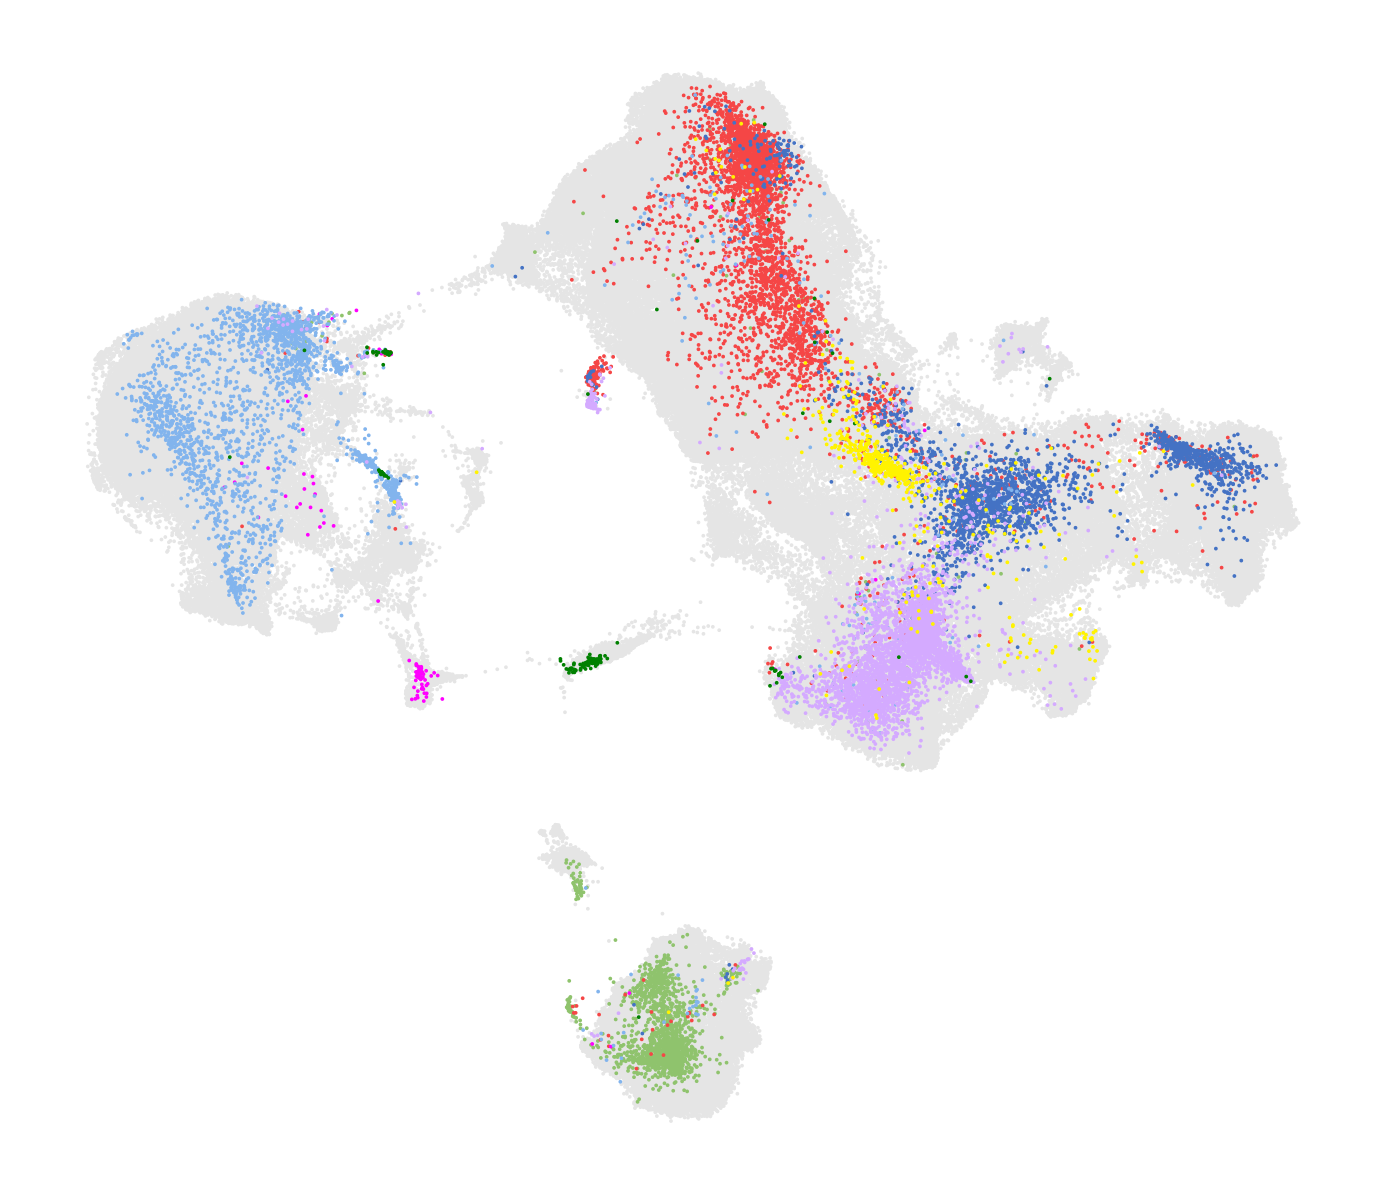

In [ ]:
save_dir <- "./analysis/fig"
w =(L + 1.5)
h = L
plt_size(w, h)
plt <- p1 + theme(legend.position = "none") 
plt
ggsave(plot = plt, file = pj(save_dir, "atlas_disease_2_umap_Seurat.png"), width = w, height = h, limitsize = F)

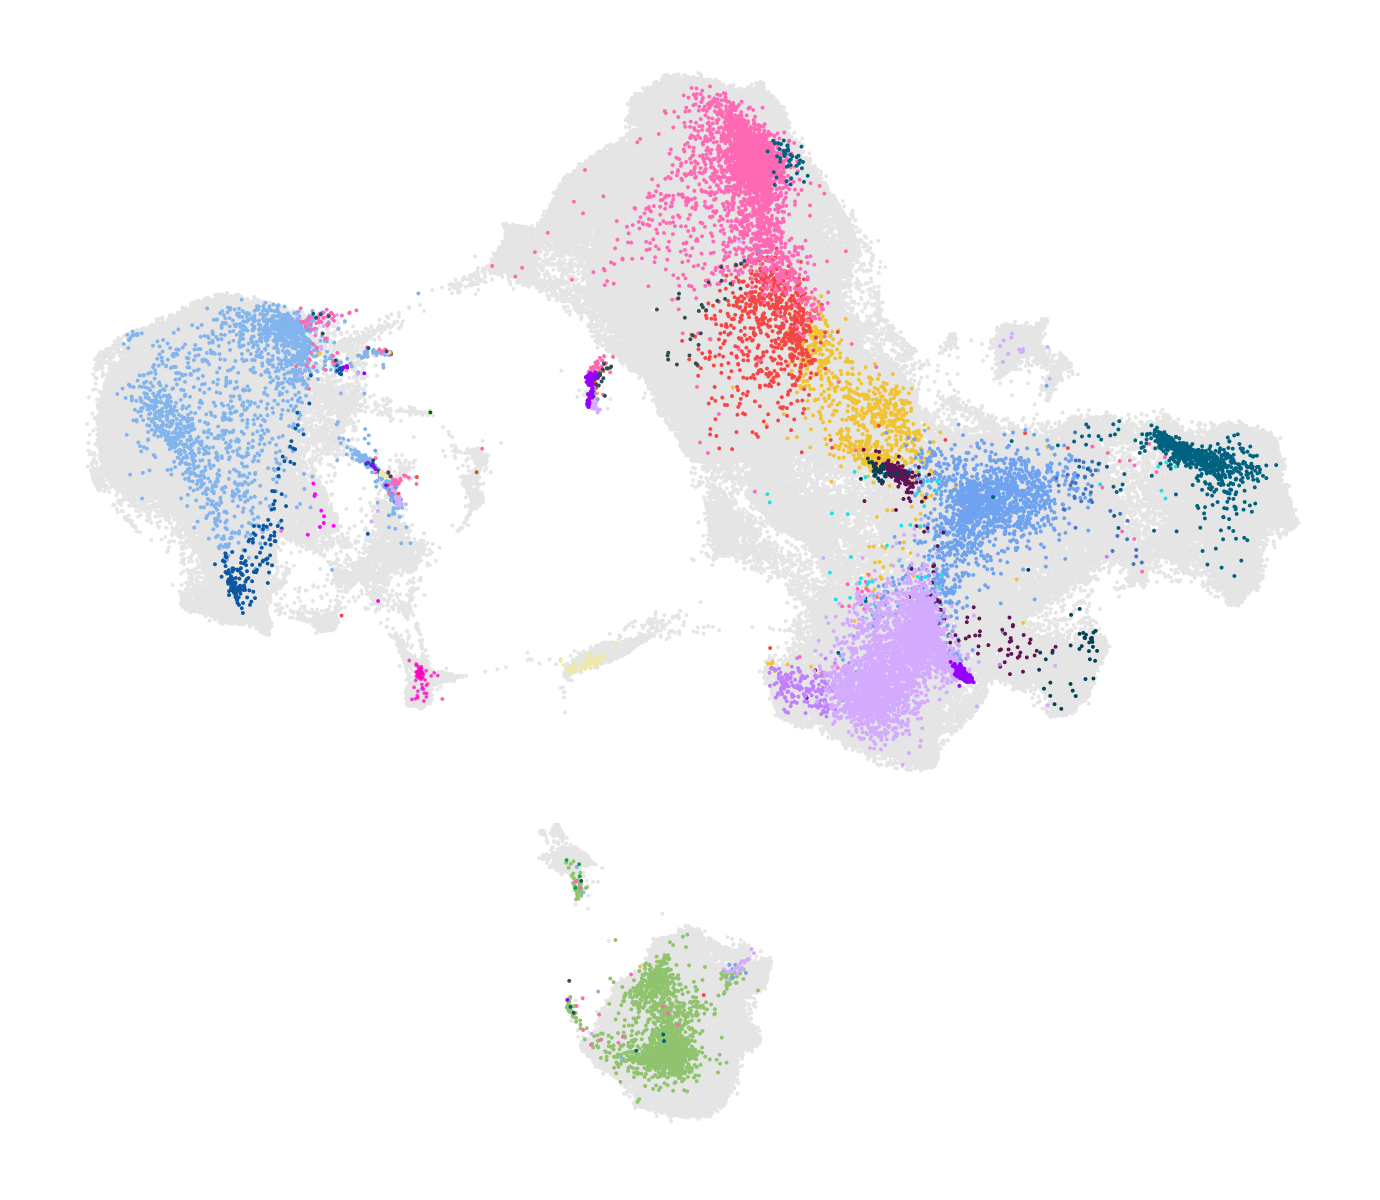

In [ ]:
save_dir <- "./analysis/fig"
w =(L + 1.5)
h = L
plt_size(w, h)
plt <- p2 + theme(legend.position = "none") 
plt
ggsave(plot = plt, file = pj(save_dir, "atlas_disease_2_umap_MIRACLE.png"), width = w, height = h, limitsize = F)